Домашнее задание 7 @EvgeniaKoma

# Анализ исторических данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import scipy.stats as stats

np.random.seed(42)

## 1. Количество пользователей
уникальных всего, по дням

In [ ]:
df_ah = pd.read_csv('action_hist.csv')

# общее количество уникальных пользователей
total_users = df_ah['uid'].nunique()
print(f'Общее количество уникальных пользователей: {total_users}')

# временной промежуток исторических данных
df_ah['Ts'] = pd.to_datetime(df_ah['Ts'])
df_ah['date'] = df_ah['Ts'].dt.date
print(f'Временной промежуток данных: с {min(df_ah['date'])} до {max((df_ah['date']))} (всего {(max((df_ah['date']))-min(df_ah['date'])).days+1} дней)')


Общее количество уникальных пользователей: 50000
Временной промежуток данных: с 2019-11-19 до 2019-11-30 (всего 12 дней)


Среднее количество новых пользователей в день: 4167


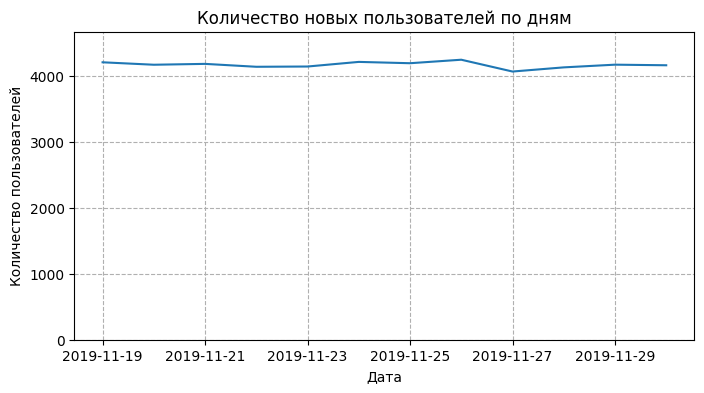

In [ ]:
# Количество новых пользователей в день (в среднем)
new_df_ah = df_ah[df_ah['Action'] == 'firstOpen'].copy()
new_df_ah['date'] = new_df_ah['Ts'].dt.date

user_per_day = new_df_ah.groupby('date')['uid'].nunique()
print(f'Среднее количество новых пользователей в день: {user_per_day.mean():.0f}')

# график количества новых пользователей по дням
plt.figure(figsize=(8, 4))
plt.plot(user_per_day.index, user_per_day.values)

plt.title('Количество новых пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True, linestyle='--')

plt.ylim(0, user_per_day.max() * 1.1)

plt.show()

## 2. Количество платящих
пользователей: всего, отдельно по подписке и по разовым покупкам

In [ ]:
df_ph = pd.read_csv('payments_hist.csv')

# общее количество платящих пользователей
total_paying_users = df_ph['uid'].nunique()
print(f'Общее количество платящих пользователей: {total_paying_users}')

# количество пользователей, оплачивающих подписку и делающих разовые покупки
podp_df_ph = df_ph[df_ph['paymentType'] == 'type1'].copy()
podp_total = podp_df_ph['uid'].nunique()

raz_df_ph = df_ph[df_ph['paymentType'] == 'type2'].copy()
raz_total = raz_df_ph['uid'].nunique()

print(f'Всего пользователей оплачивает подписку - {podp_total}')
print(f'Всего пользователей делает разовые покупки - {raz_total}')


Общее количество платящих пользователей: 25000
Всего пользователей оплачивает подписку - 10049
Всего пользователей делает разовые покупки - 17483


In [ ]:
# Есть ли пользователи, которые сделали несколько разовых покупок?
user_purchase_counts = raz_df_ph.groupby('uid').size().reset_index(name='purchase_count')

multi_buyers = user_purchase_counts[user_purchase_counts['purchase_count'] > 1]
total_multi_buyers = len(multi_buyers)

print(f'Количество человек, сделавших более одной разовой покупки: {total_multi_buyers}')

Количество человек, сделавших более одной разовой покупки: 0


In [ ]:
# тогда всего пользователей, кто и оплачивает подписку, и делает разовые покупки
10049+17483-25000

2532

In [ ]:
# те, кто и оплачивает подписку, и делает разовые покупки: что было сначала, разовая или подписка?
# предполагаем, что в начале таблицы идут более ранние платежи

# пользователи, кто оплачивает подписку И разовые покупки
podp_users = set(df_ph[df_ph['paymentType'] == 'type1']['uid'])
raz_users = set(df_ph[df_ph['paymentType'] == 'type2']['uid'])
both_users = podp_users.intersection(raz_users)

df_both = df_ph[df_ph['uid'].isin(both_users)].copy()

# оставим первый (т.е. ранний платеж)
first_payments = df_both.drop_duplicates(subset=['uid'], keep='first')

# считаем, type1 или type2 был у этих пользователей в начале
first_action_counts = first_payments['paymentType'].value_counts()
started_with_podp = first_action_counts.get('type1', 0)
started_with_raz = first_action_counts.get('type2', 0)

print(f'Сначала купили подписку, а потом сделали разовую покупку: {started_with_podp}')
print(f'Сначала сделали разовую покупку, а потом подписка: {started_with_raz}')

Сначала купили подписку, а потом сделали разовую покупку: 1251
Сначала сделали разовую покупку, а потом подписка: 1281


Поскольку данных о дате/времени покупок нет, предположим, что это несущественно

## 3. Взаимодействие с фичами
(одинаковое для платящих и неплатящих пользователей)

In [ ]:
# убираем первый вход
features_only_df = df_ah[df_ah['Action'] != 'firstOpen'].copy()

# количество уникальных фич на пользователя
user_features_count = features_only_df.groupby('uid')['Action'].nunique().reset_index(name='n')

# среднее и максимальное количество фич на одного активного пользователя
average_features = user_features_count['n'].mean()
max_features = user_features_count['n'].max()

print(f'В среднем пользователь взаимодействует с {average_features:.1f} фичами')
print(f'Максимальное количество фич, которое потрогал один пользователь: {max_features:.0f}')

В среднем пользователь взаимодействует с 1.7 фичами
Максимальное количество фич, которое потрогал один пользователь: 4


In [ ]:
# все уникальные пользователи
all_users = df_ah['uid'].unique()

# убираем первый вход
features_only_df = df_ah[df_ah['Action'] != 'firstOpen'].copy()
all_features = features_only_df['Action'].unique()

# считаем клики для тех, кто их совершал
real_clicks = features_only_df.groupby(['Action', 'uid']).size().reset_index(name='clicks_count')

# клики для каждого пользователя по каждой фиче
index = pd.MultiIndex.from_product([all_features, all_users], names=['Action', 'uid'])
full_grid = pd.DataFrame(index=index).reset_index()

final_df = pd.merge(full_grid, real_clicks, on=['Action', 'uid'], how='left')
final_df['clicks_count'] = final_df['clicks_count'].fillna(0)

# среднее по каждой фиче
feature_averages_all = final_df.groupby('Action')['clicks_count'].mean().reset_index(name='average_clicks')

print(feature_averages_all.to_string(index=False, formatters={'average_clicks': '{:.3f}'.format}))

   Action average_clicks
function1          0.200
function2          0.246
function3          0.443
function4          0.740


Данные о взаимодействии с фичами помогут, с одной стороны, оценить репрезентативность групп в тесте, с другой стороны, могут служить маркерами проблем в продукте при каких-то изменениях

## 4. Расчет стат параметров


Сначала рассмотрим конверсию в подписку:

На данный момент 10049 человек платят по 400: т.е. доход от подписки - 4019600 при конверсии в подписку 0,20098

При условии сохранения прежней конверсии в разовые покупки, общий доход от подписки сохранится на том же уровне, если 160 будут платить 25123 человека, т.е. при конверсии 0,50246 (дельта 0,30148 - абсолютный MDE)

Чтобы детектировать такой эффект, требуется следующее количество пользователей в эксперименте:

In [ ]:
# исходные данные
cr_control = podp_total/total_users
cr_test = (400*podp_total)/160/total_users

alpha = 0.05
power = 0.80

# расчет Effect Size для двух пропорций
effect_size = proportion_effectsize(cr_control, cr_test)

# размер выборки на одну группу (сплит 50 на 50)
analysis = NormalIndPower()

sample_size_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

# размер выборки итого в тесте (при сплите 50 на 50)
total_sample_size = np.ceil(sample_size_per_group) * 2

print(f'Всего требуется пользователей на тест: {total_sample_size}')

Всего требуется пользователей на тест: 76.0


Ожидаемый эффект такой большой, что для проведения теста теоретически требуемая выборка наберется меньше чем за день. Предполагая, что привлечение пользователей останется на прежнем уровне (около 4000 в день), размер выборки не будет проблемой.

При этом эксперимент все равно нужно проводить кратным 7 дням, чтобы отследить поведение пользователей и в рабочие, и в выходные дни.

Посчитаем на исторических данных ключевую метрику ARPU:
среднее значение и его дисперсию

In [ ]:
# список уникальных uid пользователей
users = df_ah[df_ah['Action'] == 'firstOpen'].copy()
users_list = pd.DataFrame({'uid': users['uid'].unique()})

# сумма поступлений на пользователя (и подписка, и разовые)
user_revenue = df_ph.groupby('uid')['Payment'].sum().reset_index(name='total_revenue')
arpu_df = pd.merge(users_list, user_revenue, on='uid', how='left')
arpu_df['total_revenue'] = arpu_df['total_revenue'].fillna(0)

# исторический ARPU, дисперсия и стандартное отклонение
hist_arpu = arpu_df['total_revenue'].mean()
hist_var = arpu_df['total_revenue'].var()
hist_std = arpu_df['total_revenue'].std()

print(f'Исторический ARPU: {hist_arpu:.2f} у. е.')
print(f'Дисперсия: {hist_var:.2f}')
print(f'Стандартное отклонение: {hist_std:.2f}')


Исторический ARPU: 150.32 у. е.
Дисперсия: 31648.93
Стандартное отклонение: 177.90


Метрика посчитана за 12 дней. Для корректного проведения теста имеет смысл заложить 2 недели.

Поскольку данные о платежах не содержат дату проведения платежа, невозможно отсмотреть окно конверсии (хватит ли одной недели для оформления пользователями подписок и разовых покупок).

# Анализ экспериментальных данных

## 1. Общее
Длительность эксперимента, количество уникальных пользователей в эксперименте

Сначала посмотрим, как шел эксперимент. Например, убедимся, что пользователи в исторических данных и данных эксперимента не пересекаются

In [ ]:
df_history_a = pd.read_csv('action_hist.csv')
df_experiment_a = pd.read_csv('Action.csv')

history_users = set(df_history_a['uid'])
experiment_users = set(df_experiment_a['uid'])

overlapping_users = list(history_users.intersection(experiment_users))
overlap_count = len(overlapping_users)

print(f'Уникальных пользователей в исторических данных: {len(history_users):,}')
print(f'Уникальных пользователей в эксперименте: {len(experiment_users):,}')
print(f'Количество пользователей, попавших в оба файла: {overlap_count}')


Уникальных пользователей в исторических данных: 50,000
Уникальных пользователей в эксперименте: 50,001
Количество пользователей, попавших в оба файла: 211


В данные эксперимента есть пользователи из исторических даннных. Для корректного анализа их стоит убрать из экспериментальных данных. Возможно, они ошибочно были включены в тест, но их поведение будет искажено, т.к. для них 160 уе будет уже скидкой

In [ ]:
# очищаем данные от старых пользователей
df_experiment_a_clean = df_experiment_a[~df_experiment_a['uid'].isin(overlapping_users)].copy()

total_users_exp = df_experiment_a_clean['uid'].nunique()
print(f'Общее количество уникальных пользователей: {total_users_exp}')

df_experiment_a_clean['Ts'] = pd.to_datetime(df_experiment_a_clean['Ts'])
df_experiment_a_clean['date'] = df_experiment_a_clean['Ts'].dt.date

min_date = min(df_experiment_a_clean['date'])
max_date = max(df_experiment_a_clean['date'])
days_delta = (max_date - min_date).days + 1
print(f'Временной промежуток данных: с {min_date} до {max_date} (всего {days_delta} дней)')

Общее количество уникальных пользователей: 49790
Временной промежуток данных: с 2020-01-09 до 2020-01-20 (всего 12 дней)


Эксперимент длился всего 12 дней, есть риск смещенной оценки из-за диспропорции рабочих/выходных дней

Среднее количество новых пользователей в день: 4526


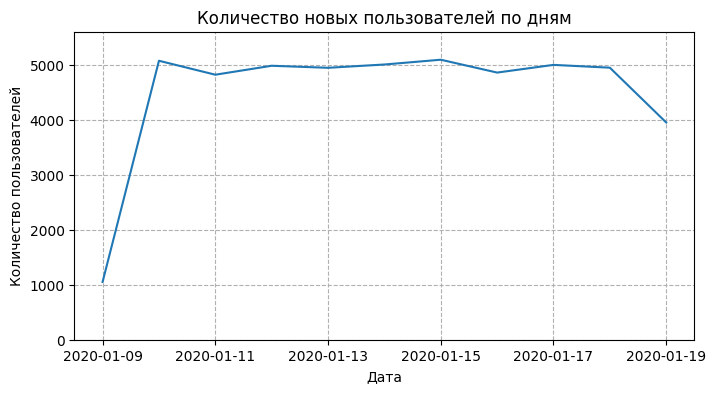

In [ ]:
# Количество новых пользователей в день (в среднем)
new_df_a = df_experiment_a_clean[df_experiment_a_clean['Action'] == 'firstOpen'].copy()
new_df_a['date'] = new_df_a['Ts'].dt.date

user_per_day_exp = new_df_a.groupby('date')['uid'].nunique()
print(f'Среднее количество новых пользователей в день: {user_per_day_exp.mean():.0f}')

# график количества новых пользователей по дням
plt.figure(figsize=(8, 4))
plt.plot(user_per_day_exp.index, user_per_day_exp.values)

plt.title('Количество новых пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True, linestyle='--')

plt.ylim(0, user_per_day_exp.max() * 1.1)

plt.show()

В первый день достаточно мало новых пользователей, вероятно эксперимент включили в середине дня, первый день с последним складывается в полные сутки. Т.е. по факту эксперимент длился 11 суток.

Получается, сервис привлекает уже по 5 тысяч пользователей в день! Ничего себе!

## 2. Проверка сплитования

Поскольку АА тест провести нельзя и сплитование можем рассматривать только уже по факту, проверяться будут:

- SRM (хи-квадрат)
- однородность и репрезентативность:
  - взаимодействие с фичами
  - участие в другом эксперименте
  - одновременность запуска


In [ ]:
df_exp_e = pd.read_csv('Experiments.csv')
# очищаем от старых пользователей
df_exp_e_clean = df_exp_e[~df_exp_e['uid'].isin(overlapping_users)].copy()

df_payment = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'paymentChange']

group_counts = df_payment.groupby('Group')['uid'].nunique()

observed_contr = group_counts.get('Old', 0)
observed_test = group_counts.get('New', 0)
total_observed = observed_contr + observed_test

# ожидаемые пропорции (так как сплит 50/50)
expected_contr = total_observed * 0.5
expected_test = total_observed * 0.5

# тест Хи-квадрат
observed = [observed_contr, observed_test]
expected = [expected_contr, expected_test]

chi2, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f'В контрольной группе: {observed_contr:,}')
print(f'В тестовой группе: {observed_test:,}')
print(f'Всего пользователей в тесте: {total_observed:,}')
print(f'p-value: {p_value:.5f}')


В контрольной группе: 24,905
В тестовой группе: 24,885
Всего пользователей в тесте: 49,790
p-value: 0.92858


SRM не обнаружено

Теперь проверка на независимость сплитования разных тестов (хи-квадрат)

In [ ]:
payment_test = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'paymentChange'][['uid', 'Group']].rename(columns={'Group': 'payment_test'})
action_test = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'actionChange'][['uid', 'Group']].rename(columns={'Group': 'action_test'})

merged_tests = pd.merge(payment_test, action_test, on='uid', how='inner')

# таблица сопряженности
crosstab = pd.crosstab(merged_tests['payment_test'], merged_tests['action_test'])

# Хи-квадрат на независимость
chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)

print(f'p-value проверки независимости: {p_value:.5f}')


p-value проверки независимости: 0.86479


Тесты ортогональны, т.е. сплитование произведено независимо, и тесты не должны друг на друга влиять

Проверка на репрезентативность через взаимодействие с фичами:

In [ ]:
# участники теста paymentChange
payment_users = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'paymentChange'][['uid', 'Group']]

# данные по фичам, без первого входа
df_exp_a = pd.read_csv('Action.csv')
df_exp_a_clean = df_exp_a[~df_exp_a['uid'].isin(overlapping_users)].copy()
features_actions = df_exp_a_clean[df_exp_a_clean['Action'] != 'firstOpen']

# общее количество взаимодействий для каждого пользователя
user_clicks = features_actions.groupby('uid').size().reset_index(name='total_clicks')

# объединяем данные
merged_activity = pd.merge(user_clicks, payment_users, on='uid', how='right')
merged_activity['total_clicks'] = merged_activity['total_clicks'].fillna(0)

clicks_contr = merged_activity[merged_activity['Group'] == 'Old']['total_clicks']
clicks_test = merged_activity[merged_activity['Group'] == 'New']['total_clicks']

# среднее число взаимодействий по группам
mean_contr = clicks_contr.mean()
mean_test = clicks_test.mean()

print(f'Среднее число взаимодействий в контрольной группе = {mean_contr:.2f}')
print(f'Среднее число взаимодействий в тестовой группе = {mean_test:.2f}')

# t-test на равенство средних (взаимодействий с фичами по группам)
t_stat, p_value_t = stats.ttest_ind(clicks_contr, clicks_test, equal_var=False)

print(f't-test p-value: {p_value_t:.5f}')


Среднее число взаимодействий в контрольной группе = 2.71
Среднее число взаимодействий в тестовой группе = 2.70
t-test p-value: 0.56567


Группы однородны

Убедимся, что эксперимент запустился и завершился одновременно для контрольной и тестовой группы

In [ ]:
df_exp = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'paymentChange'][['uid', 'Group']]

df_action = df_exp_a_clean
df_action['Ts'] = pd.to_datetime(df_action['Ts'])

# отбираем только firstOpen
first_open_actions = df_action[df_action['Action'] == 'firstOpen'][['uid', 'Ts']]

# находим первый вход для групп (самый ранний и самый поздний)
merged_time = pd.merge(first_open_actions, df_exp, on='uid', how='inner')
time_check = merged_time.groupby('Group')['Ts'].agg(['min', 'max']).reset_index()

# разница между группами
start_diff = abs((time_check.loc[0, 'min'] - time_check.loc[1, 'min']).total_seconds())
end_diff = abs((time_check.loc[0, 'max'] - time_check.loc[1, 'max']).total_seconds())

print(f'Разница старта между группами: {start_diff / 60:.1f} минут')
print(f'Разница завершения между группами: {end_diff / 60:.1f} минут')

Разница старта между группами: 0.7 минут
Разница завершения между группами: 0.7 минут


## 3. Анализ результатов

### ARPU

Непрерывная метрика - Welch t-test, бутстрап

In [ ]:
df_payment = pd.read_csv('Payment.csv')
test_users = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'paymentChange'][['uid', 'Group']]

# суммарный доход для каждого пользователя
user_revenue = df_payment.groupby('uid')['Payment'].sum().reset_index(name='total_payment')

arpu_data = pd.merge(test_users, user_revenue, on='uid', how='left')
arpu_data['total_payment'] = arpu_data['total_payment'].fillna(0)

# доход по группам в тесте
revenue_contr = arpu_data[arpu_data['Group'] == 'Old']['total_payment']
revenue_test = arpu_data[arpu_data['Group'] == 'New']['total_payment']

arpu_contr = revenue_contr.mean()
arpu_test = revenue_test.mean()

print(f'Средний ARPU в контрольной группе = {arpu_contr:.2f} у.е.')
print(f'Средний ARPU в тестовой группе = {arpu_test:.2f} у.е.')

# Welch t-test
t_stat, p_val_t = stats.ttest_ind(revenue_contr, revenue_test, equal_var=False)
print(f'Welch t-test: p-value = {p_val_t:.5f}')

# бутстрап
def get_bootstrap_p_value(sample1, sample2, n_bootstrap=2000):

    control = sample1.values
    variant = sample2.values
    boot_diffs = []

    for _ in range(n_bootstrap):
        c_sample = np.random.choice(control, size=len(control), replace=True)
        v_sample = np.random.choice(variant, size=len(variant), replace=True)

        boot_diffs.append(v_sample.mean() - c_sample.mean())

    boot_diffs = np.array(boot_diffs)

    observed_diff = variant.mean() - control.mean()
    if observed_diff > 0:
        p_val_boot = 2 * np.mean(boot_diffs <= 0)
    else:
        p_val_boot = 2 * np.mean(boot_diffs >= 0)

    p_val_boot = min(p_val_boot, 1.0)

    return p_val_boot

p_val_boot = get_bootstrap_p_value(revenue_contr, revenue_test)

print(f'Bootstrap: p-value = {p_val_boot:.5f}')


Средний ARPU в контрольной группе = 153.63 у.е.
Средний ARPU в тестовой группе = 154.52 у.е.
Welch t-test: p-value = 0.53537
Bootstrap: p-value = 0.52200


Полученное крошечное отличие статистически незначимо

### CR (подписка)

Доля - хи-квадрат

In [ ]:
podp = df_payment[df_payment['paymentType'] == 'type1']
paying_uids = set(podp['uid'])

cr_data = test_users.copy()

# 1 — купил подписку, 0 — не купил подписку
cr_data['subscr'] = cr_data['uid'].apply(lambda x: 1 if x in paying_uids else 0)

# таблица сопряженности
conversion_table = pd.crosstab(cr_data['Group'], cr_data['subscr'])

# значения конверсий
cr_cntr = conversion_table.loc['Old', 1] / conversion_table.loc['Old'].sum()
cr_test = conversion_table.loc['New', 1] / conversion_table.loc['New'].sum()

print(f'CR в контрольной группе = {cr_cntr:.2%}')
print(f'CR в тестовой группе = {cr_test:.2%}')

# Хи-квадрат
chi2, p_value, dof, expected = stats.chi2_contingency(conversion_table)

print(f'Хи-квадрат p-value = {p_value:.5f}')


CR в контрольной группе = 19.83%
CR в тестовой группе = 49.90%
Хи-квадрат p-value = 0.00000


Конверсия в подписку статистически значимо отличается в тестовой группе: +30%. (при том что конверсия в подписку в контрольной группе примерно осталась на предыдущем уровне)
Для полноценных выводов нужно убедиться, что подписка сохраняется после первого периода.

### CR (активация)
Конверсия в платящих пользователей (в сумме и по подписке, и разовые покупки)

Доля - хи-квадрат

In [ ]:
paying_uids = set(df_payment['uid'])

cr_data = test_users.copy()

# 1 — купил подписку, 0 — не купил подписку
cr_data['subscr'] = cr_data['uid'].apply(lambda x: 1 if x in paying_uids else 0)

# таблица сопряженности
conversion_table = pd.crosstab(cr_data['Group'], cr_data['subscr'])

# значения конверсий
cr_cntr = conversion_table.loc['Old', 1] / conversion_table.loc['Old'].sum()
cr_test = conversion_table.loc['New', 1] / conversion_table.loc['New'].sum()

print(f'CR в контрольной группе = {cr_cntr:.2%}')
print(f'CR в тестовой группе = {cr_test:.2%}')

# Хи-квадрат
chi2, p_value, dof, expected = stats.chi2_contingency(conversion_table)

print(f'Хи-квадрат p-value = {p_value:.5f}')

CR в контрольной группе = 49.61%
CR в тестовой группе = 68.49%
Хи-квадрат p-value = 0.00000


Конверсия в активацию статистически значимо выше в тестовой группе

### Выручка от разовых покупок на пользователя

Непрерывная метрика - Welch t-test, бутстрап

In [ ]:
df_payment = pd.read_csv('Payment.csv')
test_users = df_exp_e_clean[df_exp_e_clean['Experiment'] == 'paymentChange'][['uid', 'Group']]

# фильтр только на разовые покупки
df_payment_raz = df_payment[df_payment['paymentType'] == 'type2']

# суммарный доход от разовых покупок для каждого пользователя
user_revenue = df_payment_raz.groupby('uid')['Payment'].sum().reset_index(name='total_payment')

arpu_data = pd.merge(test_users, user_revenue, on='uid', how='left')
arpu_data['total_payment'] = arpu_data['total_payment'].fillna(0)

# доход по группам в тесте
revenue_contr = arpu_data[arpu_data['Group'] == 'Old']['total_payment']
revenue_test = arpu_data[arpu_data['Group'] == 'New']['total_payment']

arpu_contr = revenue_contr.mean()
arpu_test = revenue_test.mean()

print(f'Средний ARPU в контрольной группе = {arpu_contr:.2f} у.е.')
print(f'Средний ARPU в тестовой группе = {arpu_test:.2f} у.е.')

# Welch t-test
t_stat, p_val_t = stats.ttest_ind(revenue_contr, revenue_test, equal_var=False)
print(f'Welch t-test: p-value = {p_val_t:.5f}')

# бутстрап (Пуассон)
def get_bootstrap_p_value(sample1, sample2, n_bootstrap=2000):

    control = sample1.values
    variant = sample2.values
    boot_diffs = []

    for _ in range(n_bootstrap):
        c_sample = np.random.choice(control, size=len(control), replace=True)
        v_sample = np.random.choice(variant, size=len(variant), replace=True)

        boot_diffs.append(v_sample.mean() - c_sample.mean())

    boot_diffs = np.array(boot_diffs)

    observed_diff = variant.mean() - control.mean()
    if observed_diff > 0:
        p_val_boot = 2 * np.mean(boot_diffs <= 0)
    else:
        p_val_boot = 2 * np.mean(boot_diffs >= 0)

    p_val_boot = min(p_val_boot, 1.0)

    return p_val_boot

p_val_boot = get_bootstrap_p_value(revenue_contr, revenue_test)

print(f'Bootstrap: p-value = {p_val_boot:.5f}')

Средний ARPU в контрольной группе = 74.31 у.е.
Средний ARPU в тестовой группе = 74.68 у.е.
Welch t-test: p-value = 0.66679
Bootstrap: p-value = 0.66500


Изменения среднего дохода от разовых покупок в расчете на пользователя статистически незначимы

### CR (разовые покупки)
(в данном сетапе практически должна повторять предыдущий тест, в реальной жизни при разной стоимости разовых покупок может быть информативна)

Доля - хи-квадрат

In [ ]:
raz = df_payment[df_payment['paymentType'] == 'type2']
paying_uids = set(raz['uid'])

cr_data = test_users.copy()

# 1 — купил подписку, 0 — не купил подписку
cr_data['subscr'] = cr_data['uid'].apply(lambda x: 1 if x in paying_uids else 0)

# таблица сопряженности
conversion_table = pd.crosstab(cr_data['Group'], cr_data['subscr'])

# значения конверсий
cr_cntr = conversion_table.loc['Old', 1] / conversion_table.loc['Old'].sum()
cr_test = conversion_table.loc['New', 1] / conversion_table.loc['New'].sum()

print(f'CR в контрольной группе = {cr_cntr:.2%}')
print(f'CR в тестовой группе = {cr_test:.2%}')

# Хи-квадрат
chi2, p_value, dof, expected = stats.chi2_contingency(conversion_table)

print(f'Хи-квадрат p-value = {p_value:.5f}')

CR в контрольной группе = 37.15%
CR в тестовой группе = 37.34%
Хи-квадрат p-value = 0.67353


Ожидаемо, различие в конверсиях в разовые покупки статистически незначимо

### Взаимодействие с фичами
Популярность различных функций в сумме по контрольной и тестовой группе

In [ ]:
# все уникальные пользователи
all_users = test_users.copy()
all_users['uid'] = all_users['uid'].astype(str).str.strip()

# убираем первый вход
features_only_df = df_exp_a_clean[df_exp_a_clean['Action'] != 'firstOpen'].copy()
features_only_df['uid'] = features_only_df['uid'].astype(str).str.strip()

# Оставляем только те действия, которые совершили пользователи, участвующие в этом тесте
features_only_df = features_only_df[features_only_df['uid'].isin(all_users['uid'])]

# Считаем общее количество уникальных пользователей в тесте
total_users_count = all_users['uid'].nunique()

# клики для каждого пользователя по каждой фиче (оптимизированный подсчет суммы)
feature_counts = features_only_df.groupby('Action').size().reset_index(name='total_clicks')

# среднее по каждой фиче
feature_counts['average_clicks'] = feature_counts['total_clicks'] / total_users_count
feature_averages_all = feature_counts[['Action', 'average_clicks']]

print(feature_averages_all.to_string(index=False, formatters={'average_clicks': '{:.3f}'.format}))

   Action average_clicks
function1          0.549
function2          0.552
function3          0.801
function4          0.802
